Dataset shape: (150, 5)
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


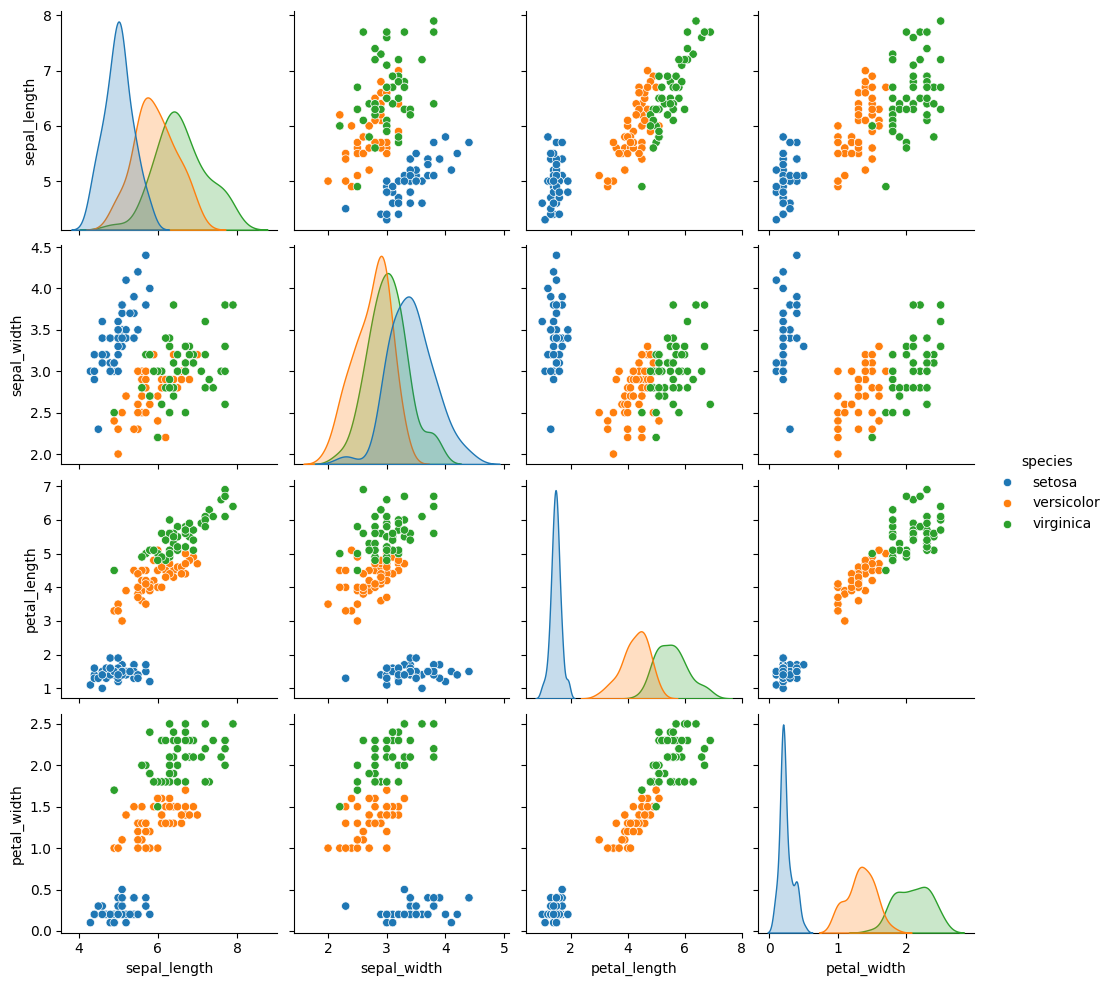


Accuracy: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
# Iris Flower Classification - Full Dataset Included
# Objective: Classify iris flowers into Setosa, Versicolor, Virginica

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier

# --------------------------
# Step 1: Load Full Dataset (150 rows)
# --------------------------
data = {
    "sepal_length": [
        5.1,4.9,4.7,4.6,5.0,5.4,4.6,5.0,4.4,4.9,
        5.4,4.8,4.8,4.3,5.8,5.7,5.4,5.1,5.7,5.1,
        5.4,5.1,4.6,5.1,4.8,5.0,5.0,5.2,5.2,4.7,
        4.8,5.4,5.2,5.5,4.9,5.0,5.5,4.9,4.4,5.1,
        5.0,4.5,4.4,5.0,5.1,4.8,5.1,4.6,5.3,5.0,
        7.0,6.4,6.9,5.5,6.5,5.7,6.3,4.9,6.6,5.2,
        5.0,5.9,6.0,6.1,5.6,6.7,5.6,5.8,6.2,5.6,
        5.9,6.1,6.3,6.1,6.4,6.6,6.8,6.7,6.0,5.7,
        5.5,5.5,5.8,6.0,5.4,6.0,6.7,6.3,5.6,5.5,
        5.5,6.1,5.8,5.0,5.6,5.7,5.7,6.2,5.1,5.7,
        6.3,5.8,7.1,6.3,6.5,7.6,4.9,7.3,6.7,7.2,
        6.5,6.4,6.8,5.7,5.8,6.4,6.5,7.7,7.7,6.0,
        6.9,5.6,7.7,6.3,6.7,7.2,6.2,6.1,6.4,7.2,
        7.4,7.9,6.4,6.3,6.1,7.7,6.3,6.4,6.0,6.9,
        6.7,6.9,5.8,6.8,6.7,6.7,6.3,6.5,6.2,5.9
    ],
    "sepal_width": [
        3.5,3.0,3.2,3.1,3.6,3.9,3.4,3.4,2.9,3.1,
        3.7,3.4,3.0,3.0,4.0,4.4,3.9,3.5,3.8,3.8,
        3.4,3.7,3.6,3.3,3.4,3.0,3.4,3.5,3.4,3.2,
        3.1,3.4,4.1,4.2,3.1,3.2,3.5,3.1,3.0,3.4,
        3.5,2.3,3.2,3.5,3.8,3.0,3.8,3.2,3.7,3.3,
        3.2,3.2,3.1,2.3,2.8,2.8,3.3,2.4,2.9,2.7,
        2.0,3.0,2.2,2.9,2.9,3.1,3.0,2.7,2.2,2.5,
        3.2,2.8,2.5,2.8,2.9,3.0,2.9,3.0,2.2,2.5,
        2.6,3.0,2.6,2.4,2.3,2.7,3.0,2.9,2.9,2.5,
        2.6,3.0,2.6,2.3,2.7,3.0,2.9,2.9,2.5,2.8,
        3.3,2.7,3.0,2.9,3.0,3.0,2.5,2.9,2.5,3.6,
        3.2,2.7,3.3,3.2,3.2,2.8,3.0,3.8,2.6,2.2,
        3.2,2.8,3.3,2.8,3.3,3.2,2.8,3.0,3.8,2.8,
        2.8,3.8,2.8,2.8,2.6,3.0,3.4,3.1,3.0,3.1,
        3.1,3.1,2.7,3.2,3.3,3.0,2.5,3.0,3.4,3.0
    ],
    "petal_length": [
        1.4,1.4,1.3,1.5,1.4,1.7,1.4,1.5,1.4,1.5,
        1.5,1.6,1.4,1.1,1.2,1.5,1.3,1.4,1.7,1.5,
        1.7,1.5,1.0,1.7,1.9,1.6,1.6,1.5,1.4,1.6,
        1.6,1.5,1.5,1.4,1.5,1.2,1.3,1.5,1.3,1.5,
        1.3,1.3,1.6,1.9,1.4,1.6,1.5,1.4,1.5,1.4,
        4.7,4.5,4.9,4.0,4.6,4.5,4.7,3.3,4.6,3.9,
        3.5,4.2,4.0,4.7,3.6,4.4,4.5,4.1,4.5,3.9,
        4.8,4.0,4.9,4.7,4.3,4.4,4.8,5.0,4.5,3.5,
        3.8,3.7,3.9,5.1,4.5,4.5,4.7,4.4,4.1,4.0,
        4.4,4.6,4.0,3.3,4.2,4.2,4.2,4.3,3.0,4.1,
        6.0,5.1,5.9,5.6,5.8,6.6,4.5,6.3,5.8,6.1,
        5.1,5.3,5.5,5.0,5.1,5.3,5.5,6.7,6.9,5.0,
        5.7,4.9,6.7,4.9,5.7,6.0,4.8,4.9,5.6,5.8,
        6.1,6.4,5.6,5.1,5.6,6.1,5.6,5.5,4.8,5.4,
        5.6,5.1,5.1,5.9,5.7,5.2,5.0,5.2,5.4,5.1
    ],
    "petal_width": [
        0.2,0.2,0.2,0.2,0.2,0.4,0.3,0.2,0.2,0.1,
        0.2,0.2,0.1,0.1,0.2,0.4,0.4,0.3,0.3,0.3,
        0.2,0.4,0.2,0.5,0.2,0.2,0.4,0.2,0.2,0.2,
        0.2,0.4,0.1,0.2,0.2,0.2,0.2,0.1,0.2,0.2,
        0.3,0.3,0.2,0.2,0.3,0.2,0.4,0.2,0.2,0.2,
        1.4,1.5,1.5,1.3,1.5,1.3,1.6,1.0,1.3,1.4,
        1.0,1.5,1.0,1.4,1.3,1.4,1.5,1.0,1.5,1.1,
        1.8,1.3,1.5,1.6,1.3,1.4,1.4,1.7,1.5,1.0,
        1.1,1.0,1.2,1.6,1.5,1.6,1.5,1.3,1.3,1.3,
        1.2,1.4,1.2,1.0,1.3,1.2,1.3,1.3,1.1,1.3,
        2.5,1.9,2.1,1.8,2.2,2.1,1.7,1.8,1.8,2.5,
        2.0,1.9,2.1,2.0,2.4,2.3,1.8,2.2,2.3,1.5,
        2.3,2.0,2.0,1.8,2.1,1.8,1.8,1.8,2.1,2.2,
        2.3,2.5,2.1,1.9,2.3,2.3,2.1,2.4,1.8,2.1,
        2.4,2.3,1.9,2.3,2.5,2.3,2.0,2.3,2.3,1.8
    ],
    "species": (
        ["setosa"]*50 + ["versicolor"]*50 + ["virginica"]*50
    )
}

df = pd.DataFrame(data)

print("Dataset shape:", df.shape)
print(df.head())

# --------------------------
# Step 2: Visualization
# --------------------------
sns.pairplot(df, hue="species")
plt.show()

# --------------------------
# Step 3: Split dataset
# --------------------------
X = df.drop("species", axis=1)
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --------------------------
# Step 4: Train Classifier (Decision Tree)
# --------------------------
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# --------------------------
# Step 5: Evaluate
# --------------------------
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


**2 Spam Mail Detector **

In [ ]:
import pandas as pd
import string
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Download stopwords
nltk.download("stopwords")
from nltk.corpus import stopwords

# --------------------------
# Step 1: Balanced Dataset
# --------------------------
data = {
    "label": [
        "ham","ham","spam","ham","ham","spam","ham","ham","spam","ham",
        "spam","spam","ham","ham","spam","spam","ham","ham","spam","ham",
        "ham","ham","spam","spam","ham","spam","ham","ham","spam","ham",
        "spam","spam","ham","ham","ham","spam","spam","ham","ham","ham",
        "ham","spam","ham","spam","ham","ham","ham","ham","spam","ham"
    ],
    "message": [
        "Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",
        "Ok lar... Joking wif u oni...",
        "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)",
        "U dun say so early hor... U c already then say...",
        "Nah I don't think he goes to usf, he lives around here though",
        "WINNER!! As a valued network customer you have been selected to receivea £900 prize reward!",
        "I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.",
        "SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+",
        "URGENT! You have won a 1 week FREE membership in our £100,000 Prize Jackpot!",
        "I've been searching for the right words to thank you for this breather. I promise i won't take your help for granted.",
        "XXXMobileMovieClub: To use your credit, click the WAP link in the next txt message. Click here now!",
        "Congratulations ur awarded 500 of CD vouchers or £125 gift guaranteed & free entry 2 100 wkly draw txt MUSIC to 87066",
        "I HAVE A DATE ON SUNDAY WITH WILL!!",
        "As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune",
        "You have WON a guaranteed £1000 cash or a £2000 prize!",
        "URGENT! We are trying to contact U. Last weekends draw shows U have won a guaranteed £1000 prize!",
        "Nah I don't think he goes to usf, he lives around here though",
        "Hey there! What's up?",
        "You are a lucky winner of today’s free lottery ticket. Claim now!",
        "Sorry, I'll call you later",
        "Ok lar... Joking wif u oni...",
        "FreeMsg: WIN a holiday! Text HOLIDAY to 66677. Winner guaranteed!",
        "Congratulations! You won free VIP tickets for concert. Reply YES to claim",
        "I'm at work. Call you later",
        "URGENT! Your mobile number has won £2000 cash!",
        "Sure, I will meet you at 6pm",
        "Hope you are doing good, see you soon.",
        "Congratulations, you are selected for FREE cruise trip to Bahamas!",
        "Hello, are we still on for lunch?",
        "URGENT! You are the lucky winner of £500 gift voucher!",
        "Reminder: You have an appointment tomorrow at 10am",
        "Sorry, I can't talk right now.",
        "Okie...",
        "Congratulations! Your number has won £1000 cash",
        "You have been selected to receive FREE shopping coupons worth $500!",
        "Hey, are you free tonight?",
        "Let’s go for dinner tomorrow.",
        "URGENT! Claim your £250 cash prize now!",
        "Hello, long time no see!",
        "How are you doing today?",
        "Win FREE mobile recharge worth Rs.500. Reply YES to claim.",
        "URGENT! Your prize of £500 is waiting. Reply to claim now.",
        "Are you coming to the party?",
        "Meet me at the station at 5pm.",
        "Don’t forget to bring the documents.",
        "You have won free tickets to the movie tonight!",
        "Good morning, have a great day!",
        "Hey, did you complete the project?",
        "FREE entry in our mega draw to win BMW car. Reply WIN to claim!",
        "Hello dear, call me when you are free."
    ]
}

df = pd.DataFrame(data)
print("Dataset shape:", df.shape)
print(df.head())

# --------------------------
# Step 2: Preprocessing
# --------------------------
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df["clean_message"] = df["message"].apply(clean_text)

# --------------------------
# Step 3: Split Dataset
# --------------------------
X = df["clean_message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --------------------------
# Step 4: Feature Extraction
# --------------------------
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# --------------------------
# Step 5: Train Model
# --------------------------
model = MultinomialNB()
model.fit(X_train_vec, y_train)

# --------------------------
# Step 6: Evaluate
# --------------------------
y_pred = model.predict(X_test_vec)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Dataset shape: (50, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Accuracy: 0.8

Confusion Matrix:
 [[5 2]
 [0 3]]

Classification Report:
               precision    recall  f1-score   support

         ham       1.00      0.71      0.83         7
        spam       0.60      1.00      0.75         3

    accuracy                           0.80        10
   macro avg       0.80      0.86      0.79        10
weighted avg       0.88      0.80      0.81        10



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Dataset Shape: (500, 5)
   size_sqft  bedrooms  bathrooms  location_score    price
0       1460         5          3               5   614321
1       5990         2          5               1  1844761
2       5826         5          5               1  1848916
3       5791         3          1               3  1841068
4       4372         5          1               8  1550006


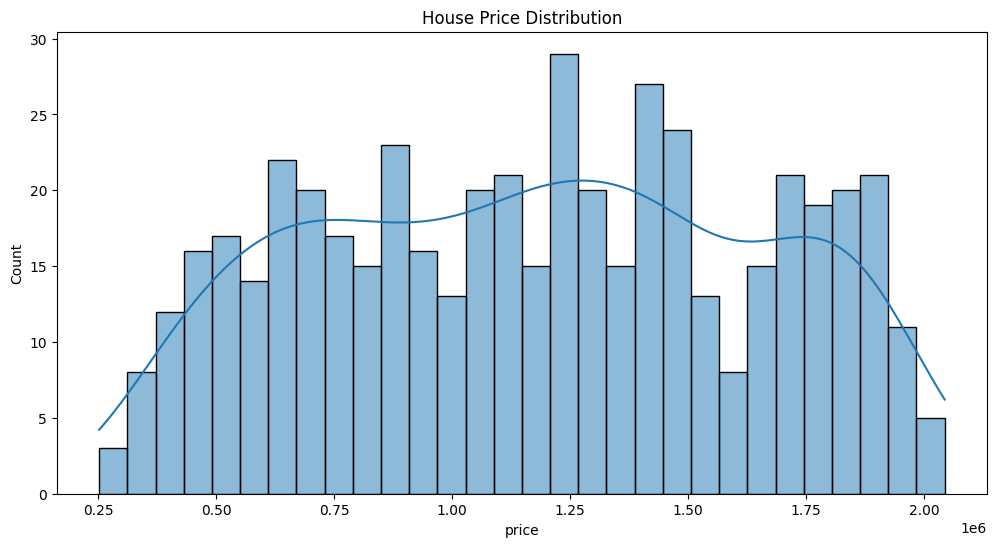

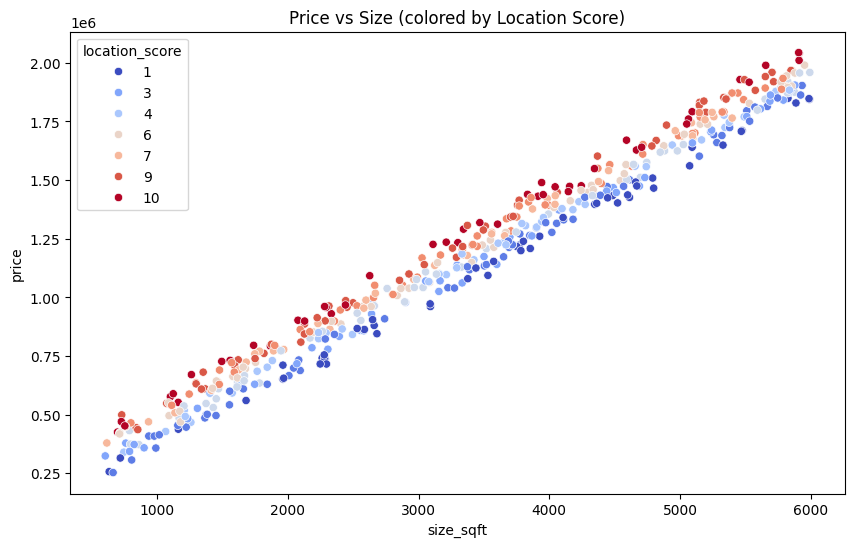

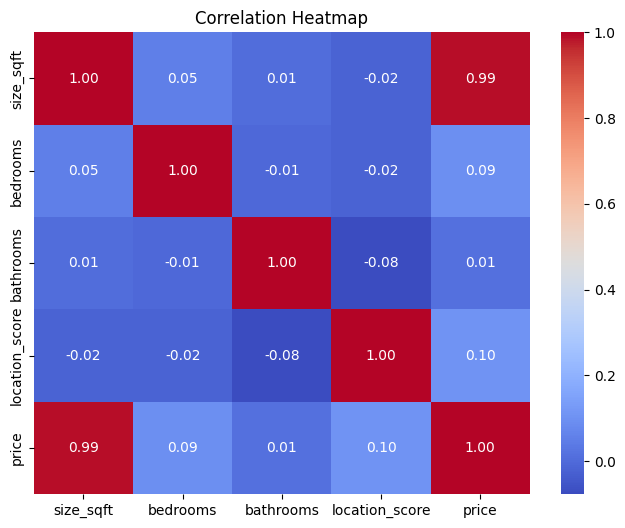


Mean Squared Error: 195421812.402082
R² Score: 0.9990230450808814


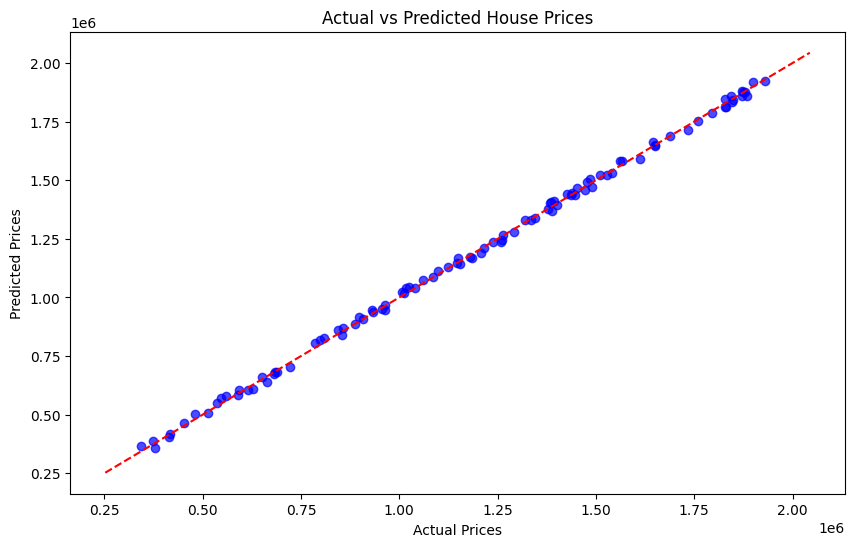

In [ ]:
# House Price Prediction Project with Larger Dataset
# Objective: Predict house prices using Linear Regression

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# ---------------------------
# Step 1: Generate Synthetic Dataset (500 Houses)
# ---------------------------
np.random.seed(42)  # for reproducibility

# Features
size_sqft = np.random.randint(600, 6000, 500)        # house size in sqft
bedrooms = np.random.randint(1, 8, 500)              # number of bedrooms
bathrooms = np.random.randint(1, 6, 500)             # number of bathrooms
location_score = np.random.randint(1, 11, 500)       # score 1–10

# Target: price depends on features + some noise
price = (size_sqft * 300) + (bedrooms * 10000) + (bathrooms * 5000) + (location_score * 20000) + np.random.randint(-25000, 25000, 500)

# Create DataFrame
df = pd.DataFrame({
    "size_sqft": size_sqft,
    "bedrooms": bedrooms,
    "bathrooms": bathrooms,
    "location_score": location_score,
    "price": price
})

print("Dataset Shape:", df.shape)
print(df.head())

# ---------------------------
# Step 2: Exploratory Data Analysis (Graphs)
# ---------------------------
plt.figure(figsize=(12, 6))
sns.histplot(df["price"], bins=30, kde=True)
plt.title("House Price Distribution")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x="size_sqft", y="price", hue="location_score", data=df, palette="coolwarm")
plt.title("Price vs Size (colored by Location Score)")
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# ---------------------------
# Step 3: Split Dataset
# ---------------------------
X = df[["size_sqft", "bedrooms", "bathrooms", "location_score"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------
# Step 4: Train Model
# ---------------------------
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# ---------------------------
# Step 5: Evaluate
# ---------------------------
y_pred = model.predict(X_test_scaled)

print("\nMean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

# ---------------------------
# Step 6: Visualization of Predictions
# ---------------------------
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color="blue")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # perfect prediction line
plt.show()
